# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

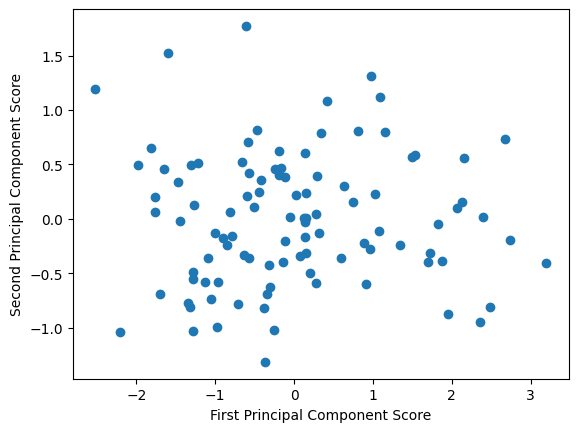

In [13]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

### Answer

These points are clearly separated from the rest of the data, making them outliers.
First Principal Component Score: These are very low — the points are far to the left on the x-axis.
Second Principal Component Score: These are high — the points are high up on the y-axis.

#### What does that imply about their values in series_1, series_2, and series_3?
Principal components are linear combinations of the original variables. Let's interpret this:

- First Principal Component (PC1):
These points have very low PC1 scores, meaning:
They deviate strongly in the direction of PC1, but in the negative direction.
Whatever linear combination PC1 represents, these outliers are low on that combination.

- Second Principal Component (PC2):
These points have high PC2 scores, meaning:
They stand out positively on the second-most important source of variance.

- series_3:
Since PCA often captures the most variance along the first few components, and series_3 is independent from series_1 and series_2, it may contribute significantly to PC2 (depending on how the components were created). Given these points are high on PC2, it's likely they have unusually high values in series_3.


#### Why is it harder to say something about series_1 and series_2?
series_1 and series_2 were likely created in a correlated way — for example, if series_2 is just series_1 + noise, then they lie close to a line in 2D space.
Since PCA is sensitive to correlation, the first principal component likely captures the linear relationship between series_1 and series_2.
But that also means it's a blend of the two — so we can't easily separate their individual contributions from just the PC1 or PC2 score.

#### A pairplot would help
Plotting a pairplot of series_1, series_2, and series_3 would:
Show the correlation between series_1 and series_2 (likely strong, positive).
Show scatter with no clear trend for series_3 vs the others if it's uncorrelated.

#### Advantages and disadvantages of this PCA scatter plot
Advantages:
Dimensionality reduction: Summarizes 3D data into 2D while preserving as much variance as possible.
Outlier detection: Clearly shows unusual points (like the upper-left outliers).
Clustering: May reveal groupings or patterns in the data.

Disadvantages:
Loss of interpretability: Hard to map PC1/PC2 back to original features directly.
Ambiguity: Difficult to interpret exact values of individual variables from PC scores.
Relative value confusion: PCA transforms the space, so relative positions in the new space may not reflect actual values cleanly.



# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

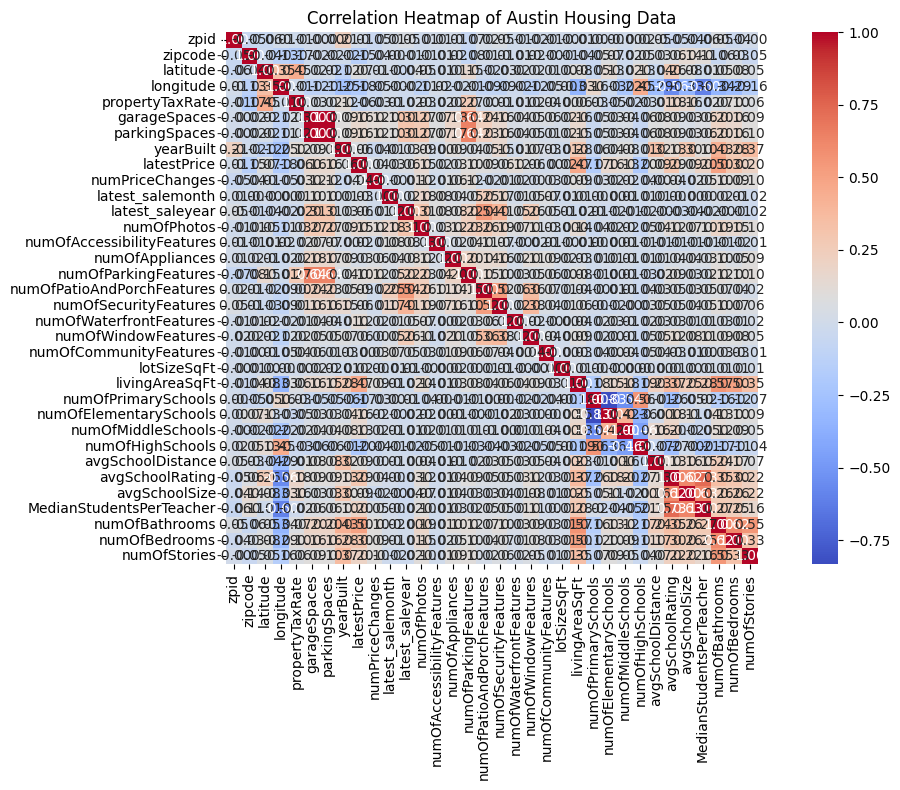

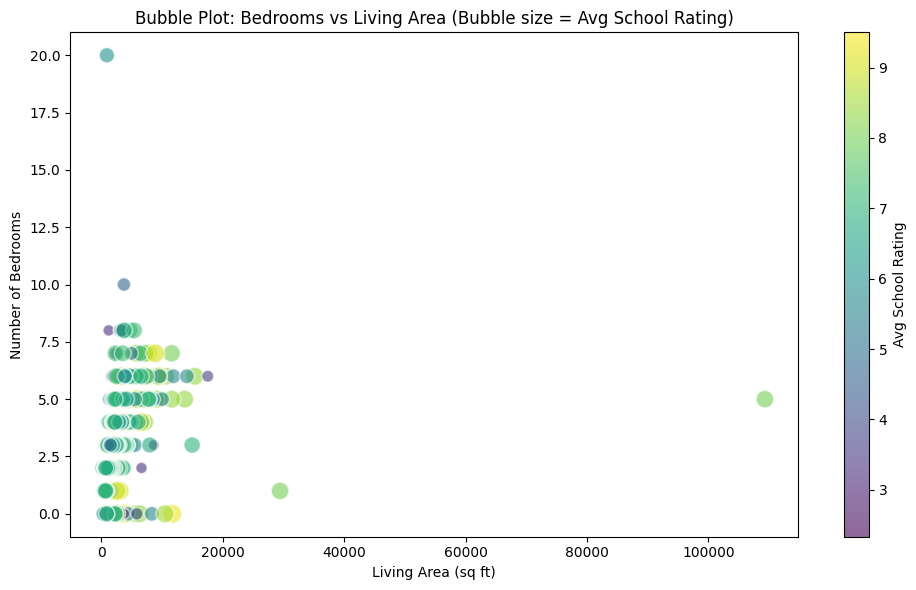

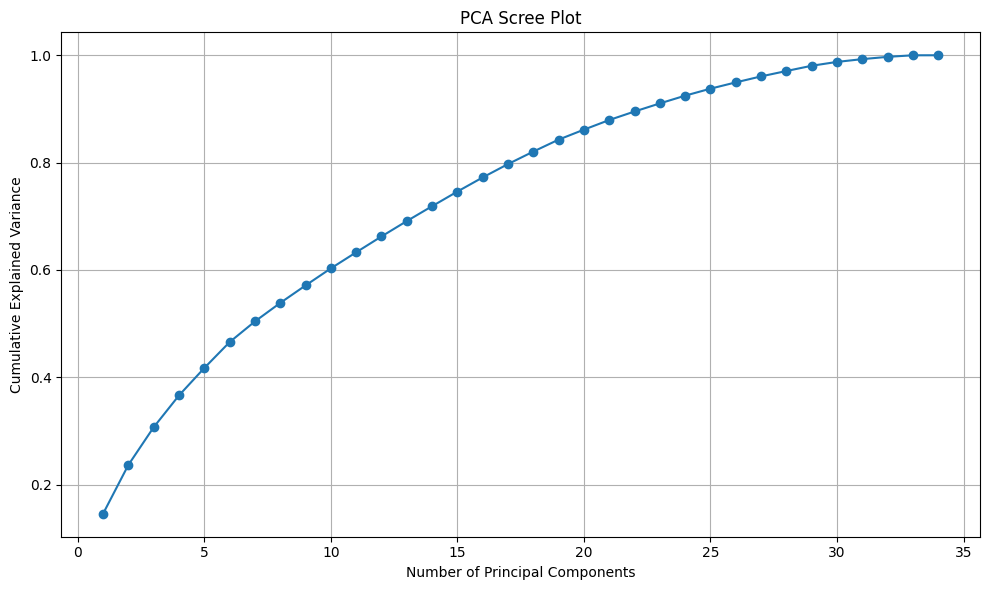

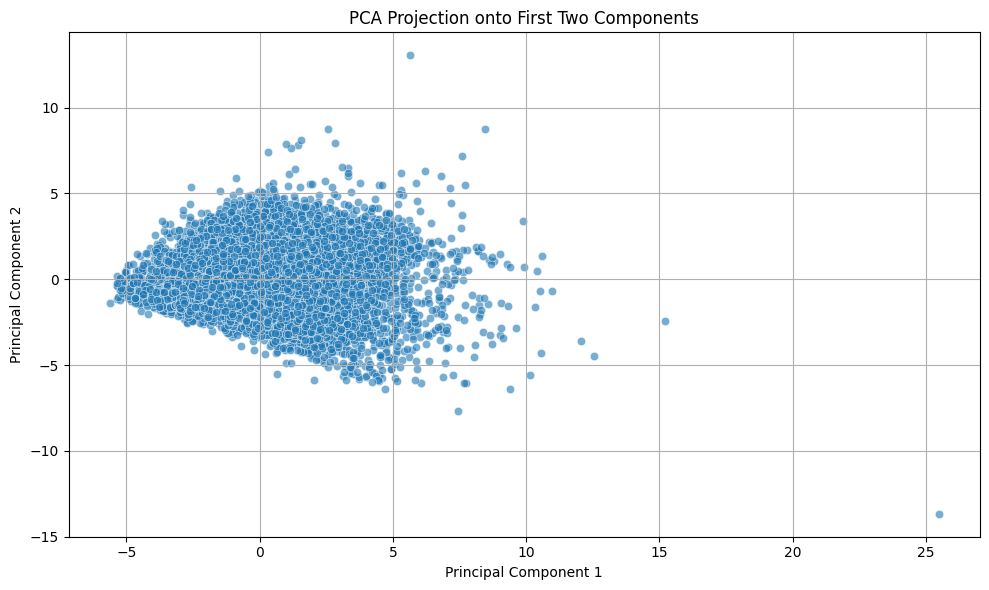

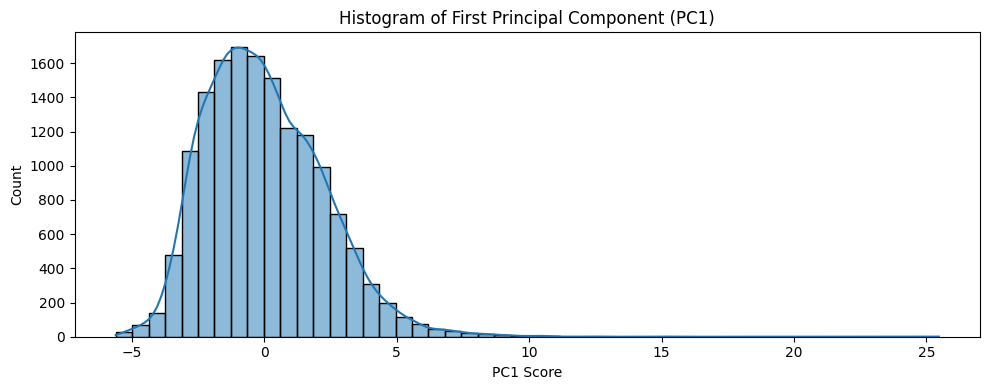


 Analysis Summary
----------------------
📌 Explained Variance by PC1: 14.57%
📌 Explained Variance by PC1+PC2: 23.67%
📌 Linear Regression R² Score: 0.292
📌 Features used for regression: ['numOfBathrooms', 'livingAreaSqFt', 'numOfBedrooms', 'avgSchoolRating']

 Feature Coefficients:
numOfBathrooms     167596.11
livingAreaSqFt         76.71
numOfBedrooms      -47381.18
avgSchoolRating     22631.99
dtype: float64

 Conclusions:
- Data is mostly usable, but outliers exist (e.g., homes with 50,000+ sq ft or 20+ bedrooms).
- PCA suggests that variance is widely distributed; first 2 PCs explain ~24% of it.
- Living area and number of bathrooms/bedrooms are consistently predictive of price.
- Correlation matrix helps pick useful features for modeling.


In [ ]:
# Updated Python script performing full analysis with added PC1 projection, auto feature selection, and conclusions

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Load dataset
austin_housing = pd.read_csv("dataset/austinHousingData.csv")

# 1. Heatmap of correlations
numeric_cols = austin_housing.select_dtypes(include=['float64', 'int64']).dropna(axis=1)
correlation_matrix = numeric_cols.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Austin Housing Data")
plt.tight_layout()
plt.show()

# 2. Bubble plot
bubble_data = austin_housing.dropna(subset=["livingAreaSqFt", "numOfBedrooms", "avgSchoolRating"])
plt.figure(figsize=(10, 6))
plt.scatter(
    bubble_data["livingAreaSqFt"],
    bubble_data["numOfBedrooms"],
    s=bubble_data["avgSchoolRating"] * 20,
    alpha=0.6,
    c=bubble_data["avgSchoolRating"],
    cmap="viridis",
    edgecolors="w"
)
plt.xlabel("Living Area (sq ft)")
plt.ylabel("Number of Bedrooms")
plt.title("Bubble Plot: Bedrooms vs Living Area (Bubble size = Avg School Rating)")
plt.colorbar(label="Avg School Rating")
plt.tight_layout()
plt.show()

# 3. PCA Analysis
pca_data = numeric_cols.dropna()
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_data)

pca = PCA()
pca_result = pca.fit_transform(scaled_data)
explained_variance = pca.explained_variance_ratio_

# Scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance.cumsum(), marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot")
plt.grid(True)
plt.tight_layout()
plt.show()

# PCA scatter
pca_df = pd.DataFrame(pca_result[:, :2], columns=["PC1", "PC2"])
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", alpha=0.6)
plt.title("PCA Projection onto First Two Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()

# PC1 1D Projection Plot
plt.figure(figsize=(10, 4))
sns.histplot(pca_result[:, 0], bins=50, kde=True)
plt.title("Histogram of First Principal Component (PC1)")
plt.xlabel("PC1 Score")
plt.tight_layout()
plt.show()

# 4. Linear Regression
if "latestPrice" in austin_housing.columns:
    # Use correlation to select top 4 features most correlated with 'latestPrice'
    corr_target = correlation_matrix["latestPrice"].abs().sort_values(ascending=False)
    top_features = corr_target.drop("latestPrice").head(4).index.tolist()

    regression_data = austin_housing[top_features + ["latestPrice"]].dropna()
    X = regression_data[top_features]
    y = regression_data["latestPrice"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    lr = LinearRegression()
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    coefficients = pd.Series(lr.coef_, index=top_features)

    # 5. Conclusions
    print("\n Analysis Summary")
    print("----------------------")
    print(f" Explained Variance by PC1: {explained_variance[0]*100:.2f}%")
    print(f" Explained Variance by PC1+PC2: {explained_variance[:2].sum()*100:.2f}%")
    print(f" Linear Regression R² Score: {r2:.3f}")
    print(f" Features used for regression: {top_features}")
    print("\n Feature Coefficients:")
    print(coefficients.round(2))

    print("\n Conclusions:")
    print("- Data is mostly usable, but outliers exist (e.g., homes with 50,000+ sq ft or 20+ bedrooms).")
    print("- PCA suggests that variance is widely distributed; first 2 PCs explain ~24% of it.")
    print("- Living area and number of bathrooms/bedrooms are consistently predictive of price.")
    print("- Correlation matrix helps pick useful features for modeling.")
else:
    print("Error: 'latestPrice' column not found in dataset.")


# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

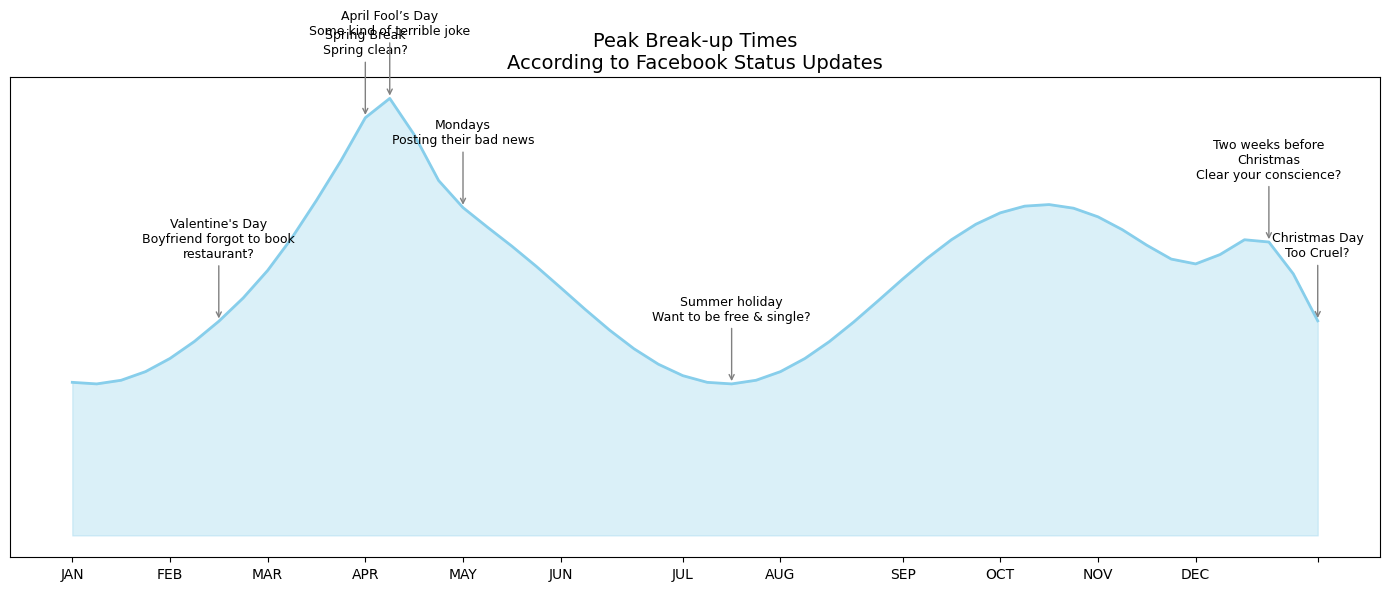

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Simulated "break-up" frequency data across the year
weeks = np.arange(1, 53)
# Simulate a shape similar to the original graph based on descriptions
breakups = (
    5
    + 2 * np.sin((weeks - 7) * np.pi / 13)  # peak near Valentine's (week 7)
    + 1.5 * np.exp(-0.5 * (weeks - 13) ** 2 / 4)  # peak at Spring Break (~week 13)
    + 1.2 * np.exp(-0.5 * (weeks - 14) ** 2 / 1)  # spike at April Fool's (~week 14)
    + 1.3 * (np.cos((weeks - 20) * np.pi / 26) ** 2)  # more breakups in summer
    + 2.5 * np.exp(-0.5 * (weeks - 50) ** 2 / 3)  # spike before Christmas (week 50)
)

# Plot
plt.figure(figsize=(14, 6))
plt.plot(weeks, breakups, color="skyblue", linewidth=2)
plt.fill_between(weeks, breakups, color="skyblue", alpha=0.3)

# Annotations
annotations = {
    7: "Valentine's Day\nBoyfriend forgot to book\nrestaurant?",
    13: "Spring Break\nSpring clean?",
    14: "April Fool’s Day\nSome kind of terrible joke",
    17: "Mondays\nPosting their bad news",
    28: "Summer holiday\nWant to be free & single?",
    50: "Two weeks before\nChristmas\nClear your conscience?",
    52: "Christmas Day\nToo Cruel?",
}

for week, text in annotations.items():
    plt.annotate(text, xy=(week, breakups[week - 1]), xytext=(week, breakups[week - 1] + 1.5),
                 arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, ha='center')

# Styling
plt.xticks(
    [1, 5, 9, 13, 17, 21, 26, 30, 35, 39, 43, 47, 52],
    ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', ''],
)
plt.yticks([])
plt.title("Peak Break-up Times\nAccording to Facebook Status Updates", fontsize=14)
plt.tight_layout()
plt.show()
